In [7]:
import geopandas as gpd
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt


In [2]:
# read in files 
study_zones = gpd.read_file("../data/study_aoi/study_firezones.shp")



In [3]:
# crop lightning netcdf file to just the study area, using just cloud-to-ground
import xarray as xr
xr.set_options(netcdf_engine_order=["netcdf4", "h5netcdf", "scipy"])

try:
    cg_2025 = xr.open_dataset("../data/raw/lightning/cg_flashes_3hr_0.1-deg_2025.nc", engine="netcdf4")
except Exception as e:
    raise RuntimeError("Failed to open netCDF with netCDF4 engine: " + str(e))

cg_2025

<xarray.Dataset> Size: 4GB
Dimensions:     (time: 2920, bnds: 2, lat: 350, lon: 950)
Coordinates:
  * time        (time) datetime64[ns] 23kB 2025-01-01 ... 2025-12-31T21:00:00
  * lat         (lat) float64 3kB 74.95 74.85 74.75 74.65 ... 40.25 40.15 40.05
  * lon         (lon) float64 8kB -144.9 -144.8 -144.8 ... -50.25 -50.15 -50.05
Dimensions without coordinates: bnds
Data variables:
    time_bnds   (time, bnds) datetime64[ns] 47kB ...
    cg_flashes  (time, lat, lon) float32 4GB ...

In [4]:
# Clip cg_2024 by study_zones (returns DataArray)


# ensure study_zones exists and is geometry-only
zones_wgs = study_zones.to_crs("EPSG:4326")

# DataArray
da = cg_2025["cg_flashes"]

# attach spatial dims and CRS (lon/lat)
da = da.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
if da.rio.crs is None:
    da = da.rio.write_crs("EPSG:4326", inplace=False)

# clip (accepts geopandas GeoSeries or list of geometries)
cg_clipped = da.rio.clip(zones_wgs.geometry.values, zones_wgs.crs, drop=True, invert=False)

# optional: convert back to Dataset with same name
cg_clipped_ds = cg_clipped.to_dataset(name="cg_flashes")
cg_clipped_da = cg_clipped  # returned object
cg_clipped_da

<xarray.DataArray 'cg_flashes' (time: 2920, lat: 39, lon: 89)> Size: 41MB
array([[[nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        ...,
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        ...,
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        ...,
...
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        ...,
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        ...,
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.]]],
      shape=(2920, 39, 89), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 23kB 2025-01-01 ... 2025-12-31T21:00:00
  * lat          (lat) float64 312B 59.95 59.85 59.75 ... 56.35 56.25 56.15
  * lon          (lon) float64 712B -128.8 -128.8 -128.6 ... -120.1 -120.0
    spatial_ref  int64 8B 0
Attributes:
    units:      1
    long_name:  frequency_of_cg_lightning_flashes_per_grid_cell_per_3hours

subset early season based on time

In [5]:
cg_clipped_da_subset = cg_clipped_da.sel(
    time=slice("2025-01-01", "2025-06-01")
)


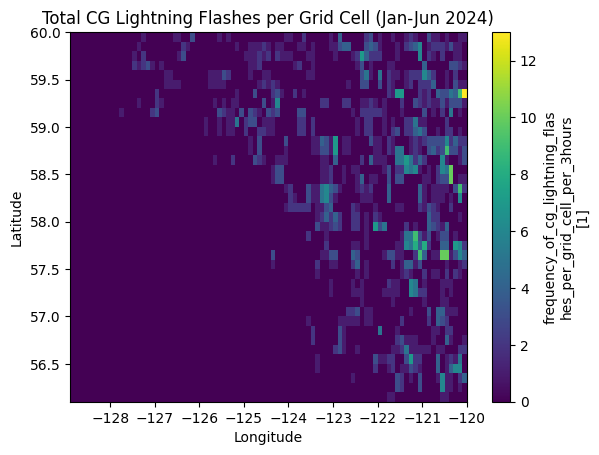

In [8]:
# count the frequency_of_cg_lightning_flashes_per_grid_cell_per_hour in the subsetted, clipped DataArray so it can be plotted as a 2D map within the study area
cg_clipped_da_subset_sum = cg_clipped_da_subset.sum(dim="time")
cg_clipped_da_subset_sum.plot()
plt.title("Total CG Lightning Flashes per Grid Cell (Jan-Jun 2024)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

<Figure size 1000x1000 with 0 Axes>

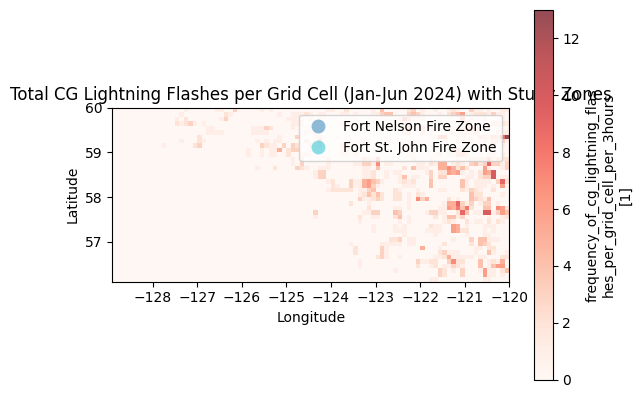

In [9]:
#plot this over the study zones plot made earlier, change colour bar label name to flashes per grid hour (assuming the original data is in flashes per grid hour)
plt.figure(figsize=(10, 10))
study_zones.plot(column="MFFRZNNM", legend=True, alpha=0.5)
cg_clipped_da_subset_sum.plot(ax=plt.gca(), cmap="Reds", alpha=0.7)
plt.title("Total CG Lightning Flashes per Grid Cell (Jan-Jun 2024) with Study Zones")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [10]:
# find the first time step with a non-zero value in the subsetted, clipped DataArray
first_nonzero_time = cg_clipped_da_subset.where(cg_clipped_da_subset > 0).dropna(dim="time", how="all").time.min().values
first_nonzero_time

np.datetime64('2025-04-11T21:00:00.000000000')

In [11]:
import xarray as xr
import numpy as np

da = cg_clipped_da_subset  # (time, lat, lon)

time_da = xr.DataArray(da.time.values.astype("datetime64[ns]"),
                       coords={"time": da.time}, dims=["time"])
first_time_per_cell = time_da.where(da > 0).min(dim="time")  # dtype datetime64[ns]

In [12]:
mask = da > 0
has_any = mask.any(dim="time")
idx = mask.argmax(dim="time")               # index of first True (if any)
first_time_per_cell = da["time"].isel(time=idx).where(has_any)

In [13]:
first_time_per_cell

<xarray.DataArray 'time' (lat: 39, lon: 89)> Size: 28kB
array([[                          'NaT',                           'NaT',
                                  'NaT', ...,
                                  'NaT', '2025-05-29T21:00:00.000000000',
        '2025-06-01T21:00:00.000000000'],
       [                          'NaT',                           'NaT',
                                  'NaT', ...,
        '2025-05-19T21:00:00.000000000', '2025-05-19T21:00:00.000000000',
                                  'NaT'],
       [                          'NaT',                           'NaT',
                                  'NaT', ...,
        '2025-05-19T21:00:00.000000000', '2025-05-19T21:00:00.000000000',
                                  'NaT'],
       ...,
       [                          'NaT',                           'NaT',
                                  'NaT', ...,
                                  'NaT', '2025-06-01T21:00:00.000000000',
        '2025-06-01T21:00:00.000000000'],
       [                          'NaT',                           'NaT',
                                  'NaT', ...,
                                  'NaT', '2025-05-19T21:00:00.000000000',
                                  'NaT'],
       [                          'NaT',                           'NaT',
                                  'NaT', ...,
                                  'NaT',                           'NaT',
                                  'NaT']],
      shape=(39, 89), dtype='datetime64[ns]')
Coordinates:
  * lat          (lat) float64 312B 59.95 59.85 59.75 ... 56.35 56.25 56.15
  * lon          (lon) float64 712B -128.8 -128.8 -128.6 ... -120.1 -120.0
    time         (lat, lon) datetime64[ns] 28kB 2025-01-01 ... 2025-01-01
    spatial_ref  int64 8B 0
Attributes:
    standard_name:  time
    long_name:      time
    bounds:         time_bnds
    axis:           T

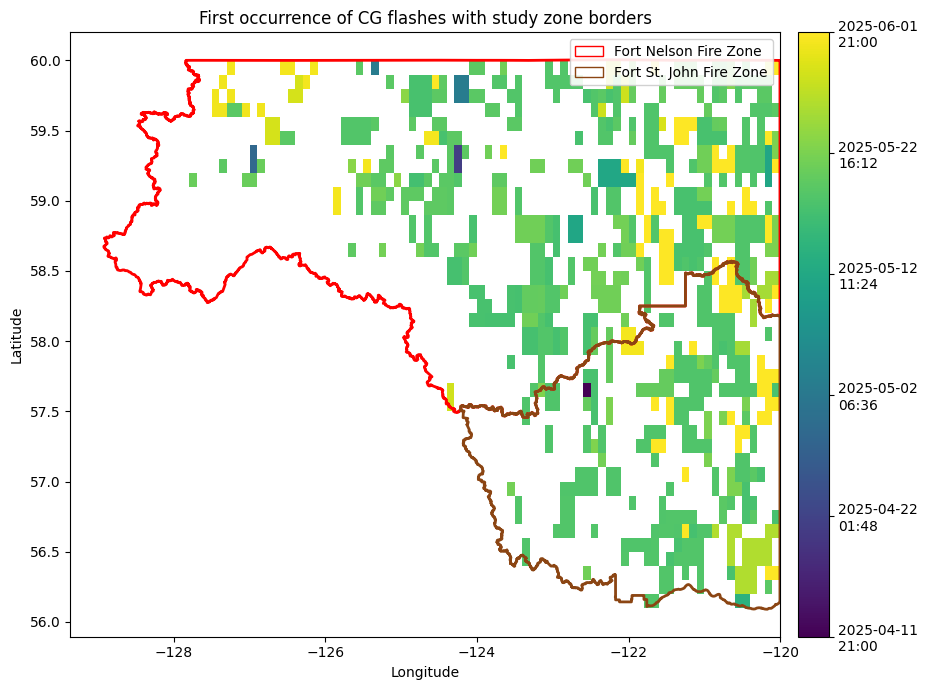

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ensure raster and zones in lon/lat
zones_wgs = study_zones.to_crs("EPSG:4326")
ft = first_time_per_cell  # must be the 2D datetime64 DataArray
ft_vals = ft.values.astype("datetime64[ns]")
ft_int = ft_vals.astype("int64").astype("float64")
ft_int[np.isnat(ft_vals)] = np.nan
lon = ft["lon"].values
lat = ft["lat"].values

# base plot: raster
fig, ax = plt.subplots(figsize=(10, 7))
pcm = ax.pcolormesh(lon, lat, ft_int, shading="auto", cmap="viridis")
cbar = fig.colorbar(pcm, ax=ax, pad=0.02)
if not np.isnan(ft_int).all():
    ticks = np.linspace(np.nanmin(ft_int), np.nanmax(ft_int), 6)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(pd.to_datetime(ticks.astype("int64")).strftime("%Y-%m-%d\n%H:%M"))

# plot all zones faintly
zones_wgs.plot(ax=ax, facecolor="none", edgecolor="lightgray", linewidth=1)

# overlay the two zones with specified colors
color_map = {"Fort Nelson Fire Zone": "red", "Fort St. John Fire Zone": "saddlebrown"}
handles = []
for name, color in color_map.items():
    sub = zones_wgs[zones_wgs["MFFRZNNM"] == name]
    if not sub.empty:
        sub.plot(ax=ax, facecolor="none", edgecolor=color, linewidth=2)
        handles.append(Patch(edgecolor=color, facecolor="none", label=name))

# legend (only for the two highlighted zones)
if handles:
    ax.legend(handles=handles, loc="upper right", framealpha=0.9)

ax.set_title("First occurrence of CG flashes with study zone borders")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

In [16]:
# save this plot to ../results/first_occurrence_map.png
import os
os.makedirs("../results", exist_ok=True)
fig.savefig("../results/lightning_first_occurrence_map_2025.png", dpi=300)

In [17]:
# save the netCDF of the clipped, subsetted DataArray to ../data/processed/cg_clipped_subset_2024.nc
os.makedirs("../data/processed_lightning", exist_ok=True)
cg_clipped_da_subset.to_netcdf("../data/processed_lightning/cg_clipped_subset_2025.nc")
first_time_per_cell.to_netcdf("../data/processed_lightning/cg_first_occurrence_2025.nc")